## P4DS Summative Assignment 2

# Data Analysis Project


# Spotify Track DB - Data Analysis


#### Student ID: 202031023


# Project Plan

## The Data (15 marks)

The dataset used in this notebook is the Spotify Tracks DB. This database is a collection of Spotify songs obtained using the Spotify API. The dataset can be found on [Kaggle](https://www.kaggle.com/yassineaboukir/spotify-songs-dataset). It contains around 200,000 songs, grouped into 26 genres, and is widely used for data exploration and analysis in the data science community.

### Key Facts

- **Source:** Spotify Web API
- **Platform:** Kaggle
- **Records:** ~200k
- **Features:** 18 columns (e.g, danceability, tempo, valence)

### Data composition
This dataset includes different types of features. First, it contains audio features such as danceability, energy, valence, acousticness, speechiness, and liveness. These describe the characteristics and mood of each song. These values are continuous and range from 0 to 1. Second, it includes technical features such as duration (in milliseconds), tempo (beats per minute), time signature (musical rhythm), and mode (the tone of the song). Finally, the dataset contains statistical data such as popularity, which is a score from 0 to 1 representing a popularity metric provided by Spotify. In addition, it includes categorical data such as genres.

### Data Accuracy
When it comes to accuracy, there are highly reliable features such as duration and tempo, since they are computed directly from the actual audio track. However, many of the audio features are calculated using Spotify’s algorithms, meaning they represent approximations rather than exact values and can be considered subjective. For instance, danceability and valence are subjective interpretations of musical qualities. Moreover, popularity is a dynamic variable influenced by current trends and seasonal patterns, making it less stable over time.

### Data Quality
The dataset is clean and does not exhibit missing values. Additionally, it is well structured and contains consistent numerical ranges. However, some observations were identified during the data exploration phase. Notably, the duration variable contains some outliers, with certain tracks exceeding 90 minutes; this is most likely because the dataset includes podcasts or live performances rather than actual songs. Moreover, several features, such as speechiness and liveness, have skewed distributions, and I will further explore the reasons behind this. Additionally, as the dataset was constructed by selecting a fixed number of songs per genre, it may be biased, as this suggests an artificial selection that may not reflect real-world listening patterns. Lastly, duplicates appear to exist across different genres.

Overall, the dataset is suitable for exploratory analysis. While it contains some limitations, such as outliers, duplicates, skewed distributions, and some level of bias, these issues can be addressed through appropriate preprocessing techniques, making the dataset valuable for analyzing musical characteristics and trends.

## Project Aim and Objectives (5 marks)

In this project the objective is to analyze and gain a deeper understanding of the Spotify Tracks DB dataset. The project focuses on exploring the structure and characteristics of the data, as well as identifying meaningful patterns and relationships between different audio features.

The first part of the project involves exploring the dataset to develop a general understanding of the type of data it contains. This includes examining the available features, their data types, and identifying the existance of missing values or duplicate entries. In addition, the analysis will investigate potential outliers and skewed distributions, and attempt to explain the reasons for their existence.

Following this, the project will analyze the relationship between different audio features, such as danceability, energy, popularity. This will be achieved using correlation analysis and visualizations techniques which will help to determine patterns between the features. Visualizations will be used to present insights in a clear interpretable way.

Finally the project aims to answers specific analytical questions by extracting relevant information from the dataset. This includes identifying the most popular artists, the most danceable songs, and the genres with highest levels of danceability.

Overall, the project combines exploratory data analysis, correlation analysis, and visualization to derive meaningful insights from the dataset.

### Specific Objective(s)

* __Objective 1:__ Implement an Exploratory Data Analysis (EDA) using a pandas dataframe.
* __Objective 2:__ Understand the relationships between different features in the Spotify DB dataset.
* __Objective 3:__ Identify relevant information like most danceable songs, most popular artists, most danceable genres.

## System Design (5 marks)

### Architecture

The system is a pipeline-based architecture in which the dataset is processed sequentially. First, the Spotify dataset is loaded from a CSV file into a pandas dataframe. The data is then analyzed by describing draft views of the rows, columns, and data types. Second, a data preparation staged is implemented where column names are renamed for consistency and non-relevant features such as ids, loudness and any other feature that is considered as a low information provider is cleaned up and dropped.

Next, filtering is applied by identifying duplicate entries and possible NA values in the dataset. The core of the system is the exploratory data analysis stage, where statistical summaries and correlation between features are presented.

Finally, the results are visualized using plots to reveal patterns and insights about musical characteristics across genres. This pipeline allows that each stage of the process is clearly separated and reproducible.

![EDA-Arch.svg](img/EDA-Arch.svg)

### Processing Modules and Algorithms

* **Data cleaning module:** This module removes duplicate entries, it was observed that a combination of severa features e.g. `Artist_Name, Track_Name, Acousticness, Danceability, Duration_Ms, Energy, Key, Liveness, Speechiness, Tempo, Time_Signature,` and `Valence` consitute a duplicate for this project since artists can release the different versions of the same track.

    Another important factor is that Pandas by default marks strings 'None' as `NA`, there is a chance that songs can be named `None` or any other value Pandas may consider `NA`. Therefore, it is important to manipulate the default behavior of Pandas when loading the csv file. In this project the specific song containinng `None` was set back to its original value.
* **Feature Analysis module:** This component computes descriptive statistics and explores the distribution of key audio features. Histograms and summary statistics are used to identify skewness and outliers.
* **Correlation Analysis module:** This module evaluates relationships between features using correlation coefficients. A correlation matrix is computed and displayed to identify dependencies between features such as energy, danceability, and popularity.
* **Visualization module:** This module generates graphical representations of the data, including bar charts and comparisons between popularity by mean and by maximums.

# Program Code (25 marks)

#### Imports
Importing required libraries.

In [1]:
import pandas as pd
from IPython.display import Markdown
import matplotlib.pylab as plt
import seaborn as sns

#### Load Data Set
Loading the data set raw and verify how it looks like.

In [2]:
df = pd.read_csv('./dataset/SpotifyFeatures.csv')

#### Data understanding
Check the shape of the data frame ~200k rows and 18 columns of data.

In [3]:
df.shape

(232725, 18)

Visualize the first 5 rows in the data frame for exploration.

In [4]:
display(Markdown("#### Songs"))
display(df.head())

#### Songs

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


Although, columns can be deducted from previous table, I would like to display all columns as list to have a consolidated view of all columns in the dataset.

In [5]:
display(Markdown("#### Song's Columns"))
df.columns

#### Song's Columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='str')

Next, I would like to verify the data type assigned to each column.

In [6]:
display(Markdown("#### Feature types"))
df.dtypes

#### Feature types

genre                   str
artist_name             str
track_name              str
track_id                str
popularity            int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                     str
liveness            float64
loudness            float64
mode                    str
speechiness         float64
tempo               float64
time_signature          str
valence             float64
dtype: object

Show some information and statistics about the numeric data the dataset contains.

In [7]:
display(Markdown("#### Dataset describe"))
df.describe()

#### Dataset describe

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


#### Data Preparation
In order to focus on the columns that provide relevant information for the analysis in this project, I will next remove the following columns, which may be interesting to examine but will be excluded for now.

In [8]:
df = df.drop(['track_id', 'loudness', 'mode', 'instrumentalness'], axis=1).copy()

Check that indeed previous columns have been removed from the dataset.

In [9]:
df.shape

(232725, 14)

In the next cell, I check the consistency of the column names.

In [10]:
df.columns

Index(['genre', 'artist_name', 'track_name', 'popularity', 'acousticness',
       'danceability', 'duration_ms', 'energy', 'key', 'liveness',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='str')

In this case, it looks quite consistent. However, I would like to have the first and second letter capitalized.

In [11]:
df.columns = [col.title() for col in df.columns]

Check that column names are correctly capitalized.

In [12]:
df.head()

,Genre,Artist_Name,Track_Name,Popularity,Acousticness,Danceability,Duration_Ms,Energy,Key,Liveness,Speechiness,Tempo,Time_Signature,Valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0,0.611,0.389,99373,0.910,C#,0.3460,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),1,0.246,0.590,137373,0.737,F#,0.1510,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,3,0.952,0.663,170267,0.131,C,0.1030,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0,0.703,0.240,152427,0.326,C#,0.0985,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,4,0.950,0.331,82625,0.225,F,0.2020,0.0456,140.576,4/4,0.390


In order to identify whether there are missing values in the dataset and how often they occur, the following command is executed.

In [13]:
df.isna().sum()

Genre             0
Artist_Name       0
Track_Name        1
Popularity        0
Acousticness      0
Danceability      0
Duration_Ms       0
Energy            0
Key               0
Liveness          0
Speechiness       0
Tempo             0
Time_Signature    0
Valence           0
dtype: int64

There seems to be one missing value in Track_Name, so in order to visualize it I run the following cell.

In [14]:
df[df['Track_Name'].isna()]

,Genre,Artist_Name,Track_Name,Popularity,Acousticness,Danceability,Duration_Ms,Energy,Key,Liveness,Speechiness,Tempo,Time_Signature,Valence
208285,World,Elevation Worship,NaN,44,0.019,0.287,350027,0.446,F,0.1,0.0317,138.727,4/4,0.0387


At this point I realized that band **Elevation Worship** has an actual song called _"None"_ and that when pandas loads the file with `read_csv()` it automatically interprets song's name _"None"_ as `NA`. Therefore there are two possibilities either tell pandas not to treat string _"None"_ as `NA` when loading the csv as follows:

In [15]:
df_raw = pd.read_csv('./dataset/SpotifyFeatures.csv', keep_default_na=False)
df_raw.loc[df_raw['track_name'] == 'None', ['artist_name', 'track_name']].head()

,artist_name,track_name
208285,Elevation Worship,None


Or fill the `Track_Name` value back with string _"None"_. I will continue with this approach for simplicity and illustration. However, it is more robust to fix it at the data loading stage.

In [16]:
df.loc[
    (df['Artist_Name'] == 'Elevation Worship') & (df['Track_Name'].isna()),
    'Track_Name'
] = 'None'

Proving that the track has the original song's name set back to _"None"_

In [17]:
df['Track_Name'].isna().sum()
df.loc[df['Track_Name'] == 'None']

,Genre,Artist_Name,Track_Name,Popularity,Acousticness,Danceability,Duration_Ms,Energy,Key,Liveness,Speechiness,Tempo,Time_Signature,Valence
208285,World,Elevation Worship,None,44,0.019,0.287,350027,0.446,F,0.1,0.0317,138.727,4/4,0.0387


Now I would like to check a naive set of duplicates in the dataframe. As seen below, there are ~55k entries marked as duplicates evaluating equal `Artist_Name` and `Track_Name`. However, it is important to determine what is considered a duplicate, it could be that the same artists perform different versions of the same song.

In [18]:
df.duplicated(subset=['Artist_Name', 'Track_Name']).sum()

np.int64(56211)

The very popular 90's song Creep performed by Radiohead appears 4 times. In the data it is observed that these versions are indeed duplicates because it is unlikely that the same song has same values for `Acousticness, Daceability Duration_Ms `etc.

In [19]:
df.query('Track_Name == "Creep" and Artist_Name == "Radiohead"')

,Genre,Artist_Name,Track_Name,Popularity,Acousticness,Danceability,Duration_Ms,Energy,Key,Liveness,Speechiness,Tempo,Time_Signature,Valence
1152,Alternative,Radiohead,Creep,78,0.0102,0.515,238640,0.43,G,0.129,0.0369,91.841,4/4,0.104
77167,Children’s Music,Radiohead,Creep,81,0.0102,0.515,238640,0.43,G,0.129,0.0369,91.841,4/4,0.104
92956,Indie,Radiohead,Creep,82,0.0102,0.515,238640,0.43,G,0.129,0.0369,91.841,4/4,0.104
166182,Rock,Radiohead,Creep,82,0.0102,0.515,238640,0.43,G,0.129,0.0369,91.841,4/4,0.104


Therefore, for the purpose of this project, a song will be duplicate if it contains equal values for the following features below.

In [20]:
# Select records where values are NOT duplicates of the given subset
df = df.loc[~df.duplicated(subset=[ 'Artist_Name', 'Track_Name', 'Acousticness', 'Danceability', 'Duration_Ms', 'Energy', 'Key',
                       'Liveness', 'Speechiness', 'Tempo', 'Time_Signature', 'Valence'])].reset_index(drop=True).copy()

The result after removing meaningful duplicates for this project is ~176k unique records.

In [21]:
df.shape

(176904, 14)

# Project Outcome (10 + 10 marks)

## Overview of Results
The analysis of the Spotify Tracks DB dataset revealed several meaningful patterns and relationships between audio features, as well as insights into the structure of the data. Through exploratory data analysis, it was observed that the dataset is generally well-structured, with no significant missing values, although certain features exhibit skewed distributions and the presence of outliers. For example, variables such as duration contain extreme values, while features like speechiness and liveness are heavily skewed due to the nature of the content. 

In this section, the outcomes of the project are presented through both analysis and visualisation. The results are structured according to the project objectives, with each subsection providing an explanation of the findings followed by graphical representations to support the analysis. The aim is to highlight key patterns, relationships, and insights derived from the dataset.

## Objective 1 - Feature Understanding based on Exploratory Data Analysis (EDA)

The first objective of the project was to perform an exploratory data analysis (EDA) using a pandas dataframe to understand the structure and quality of the dataset. The analysis revealed that the dataset is well-structured, with consistent numerical ranges across features and no significant missing values. This indicates that the data is suitable for further analysis without requiring extensive preprocessing.

### Visualisation
First I will start with visualizing an interesting feature which provides insights on the music signature called `Time_Signature`. I would like to understand the distribution of time signatures in this song dataset, which, unsurprisingly, is dominated by 4/4, as it is the most common rhythmic pattern in modern music, while 1/4 and 0/4 are the least frequent.


In [22]:
# Feature understanding
df['Time_Signature'].value_counts()

Time_Signature
4/4    149309
3/4     20814
5/4      4431
1/4      2344
0/4         6
Name: count, dtype: int64

Using barchart to visualize this information, we see on the x axis the time signature and y axis the count. In total there are ~14k records using 4/4 signatures in contrast to the rest with less conventional signatures. Worth to note is that 3/4 is relatively common and still many popular styles use it e.g. waltzes, folk music, ballads which may be contained in the dataset.

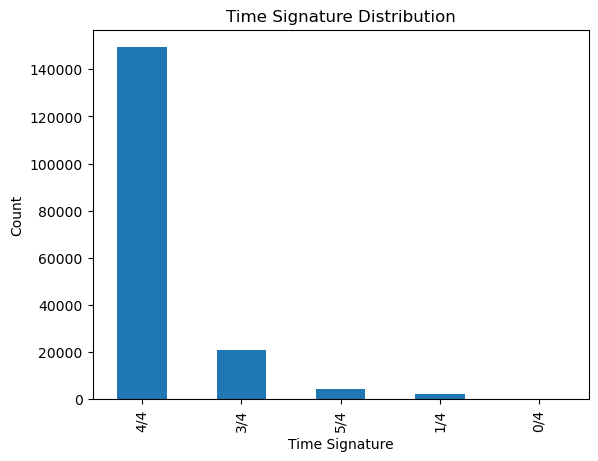

In [23]:
ax = df['Time_Signature'].value_counts().head(10).plot(kind='bar', title='Time Signature Distribution')
ax.set_xlabel('Time Signature')
ax.set_ylabel('Count')
plt.show()

In the next plot we can see in different bins what the count for the danceable songs. We see that most of the songs contained in the dataset are marked with a dancebility level of ~0.5 within a range of 0 to 1. So we can say that the majority of the songs in the dataset are half danceble under Spotify's criteria. Although there are some high danceble songs with metrics of very close to 1.

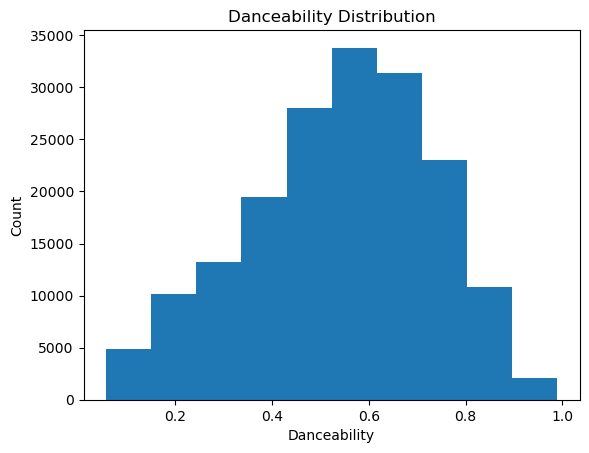

In [24]:
ax = df['Danceability'].plot(kind='hist', title='Danceability Distribution', bins=10)
ax.set_xlabel('Danceability')
ax.set_ylabel('Count')
plt.show()
# Could be cool to find the most danceble song and  play it in the video

In order to see the most danceble song rated by Spotify, we can do it by running the following cell. Interestingly, many of the top tracks belong to the Children’s Music genre. This suggests that danceability is not directly linked to typical dance genres, but rather to how the metric is defined, as well as potential dataset bias and cultural expectations.

In [25]:
df.nlargest(5, 'Danceability')

,Genre,Artist_Name,Track_Name,Popularity,Acousticness,Danceability,Duration_Ms,Energy,Key,Liveness,Speechiness,Tempo,Time_Signature,Valence
69380,Children's Music,Juice Music,Fuzzy Wuzzy,1,0.10800,0.989,93307,0.468,G,0.3000,0.0717,115.002,4/4,0.977
25876,Electronic,Quantic,Sol Clap,33,0.00167,0.987,230747,0.629,C,0.0634,0.2650,115.342,4/4,0.424
69746,Children's Music,Juice Music,I've Been Everywhere,1,0.58700,0.987,155000,0.739,G,0.0738,0.0578,119.992,4/4,0.963
80608,Hip-Hop,Pitbull,Go Girl,50,0.14500,0.986,229669,0.597,G#,0.1970,0.3080,115.004,4/4,0.761
22795,Electronic,Nu,Who Loves the Sun,58,0.18900,0.985,562239,0.686,A#,0.1930,0.0510,120.004,4/4,0.693


## Objective 2 - Relationships Between Features (Data Outliers)

This objective focused on understanding the relationships between different features in the dataset. Correlation analysis and visualisation techniques were used to identify patterns and dependencies between variables. The results show that most features have weak to moderate correlations, indicating that many aspects of this music operate independently.

In addition, an outlier investigation was conducted to assess the impact of extreme values on the analysis. It was observed that certain features, particularly duration, contain significant outliers that could distort statistical measures and visualisations. These outliers were analysed and interpreted as non-standard tracks, such as podcasts or live recordings. This step was important to ensure that the relationships identified between features were not misleading due to extreme values.

First I start with the outlier investigation followed by a correlation analysis.


### Visualisation

In order to analyze the data, I will perform first a naive outlier report flagging 5th percentile as the lower cutoff and 95th as the upper cutoff. This means slicing the bottom 5% and the top 5% to potentially identify anomalies in the data.

In [26]:
# Initialize data structures
outlier_report = []
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Loop through each numeric column
for col in numeric_features:

    # Define bounds using 5th and 95th percentiles
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)

    # Identify extremes or outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Build report entry
    outlier_report.append({
        'Feature': col,
        'Outlier Count': len(outliers),
        'Percentage': f"{(len(outliers) / len(df) * 100):.2f}%",
        '5th Percentile': lower_bound,
        '95th Percentile': upper_bound,
        'Min Outlier': outliers[col].min() if not outliers.empty else 'N/A',
        'Max Outlier': outliers[col].max() if not outliers.empty else 'N/A'
    })

In the report it can be seen that ~10% of the data for every feature will be marked as outlier. And although, not all values are outliers it certainly shows some suspicious values, such as `Duration_Ms` where the minimum value is 15 seconds and maximum is ~92 mins. Clearly not a normal song, and possibly a podcast, live concerts, or data errors.

In [27]:
# Display the report
df_percentile_outliers = pd.DataFrame(outlier_report).sort_values(by='Outlier Count', ascending=False)
display(df_percentile_outliers)

,Feature,Outlier Count,Percentage,5th Percentile,95th Percentile,Min Outlier,Max Outlier
3,Duration_Ms,17692,10.00%,98602.700000,413678.05000,15387.00000,5552917.000
7,Tempo,17692,10.00%,74.063300,174.08385,30.37900,242.903
4,Energy,17685,10.00%,0.064500,0.94700,0.00002,0.999
8,Valence,17677,9.99%,0.041600,0.90200,0.00000,1.000
2,Danceability,17636,9.97%,0.189000,0.82700,0.05690,0.989
5,Liveness,17636,9.97%,0.062800,0.75000,0.00967,1.000
1,Acousticness,17537,9.91%,0.000878,0.97900,0.00000,0.996
6,Speechiness,17363,9.81%,0.028600,0.78185,0.02220,0.967
0,Popularity,16379,9.26%,3.000000,64.00000,0.00000,100.000


To see more informative plots than a tail percentile table a boxplot using seaborn is plotted. Here we can see the **shape, skewness, and true outliers.** of each feature. The following are the interpretations:
* `Duration_Ms`: This is a real outlier case. Box is compressed near the left where most of the songs belong (2 to 5 mins) but there are many extreme long tracks e.g. Podcasts, live concerts, data errors
* `Tempo`: Some high tempo outliers ~200bpm, in modern commercial music usually tempo is around ~90 to 140bpm. This could mean niche genres.
*  `Popularity`: Slightly skewed to the right. However, this indicates very popular songs.
* `Liveness`: Strong skew to the right. This may look like high value outliers but it could be due to a high proportion of live performances.
* `Speechiness`: Strong skew to the right. Many song genres contain high speechiness values. e.g. Rap, Hip-Hop, Children's Music.
* `Acousticness,  Energy,  Danceability, Valence`: No strong outliers.

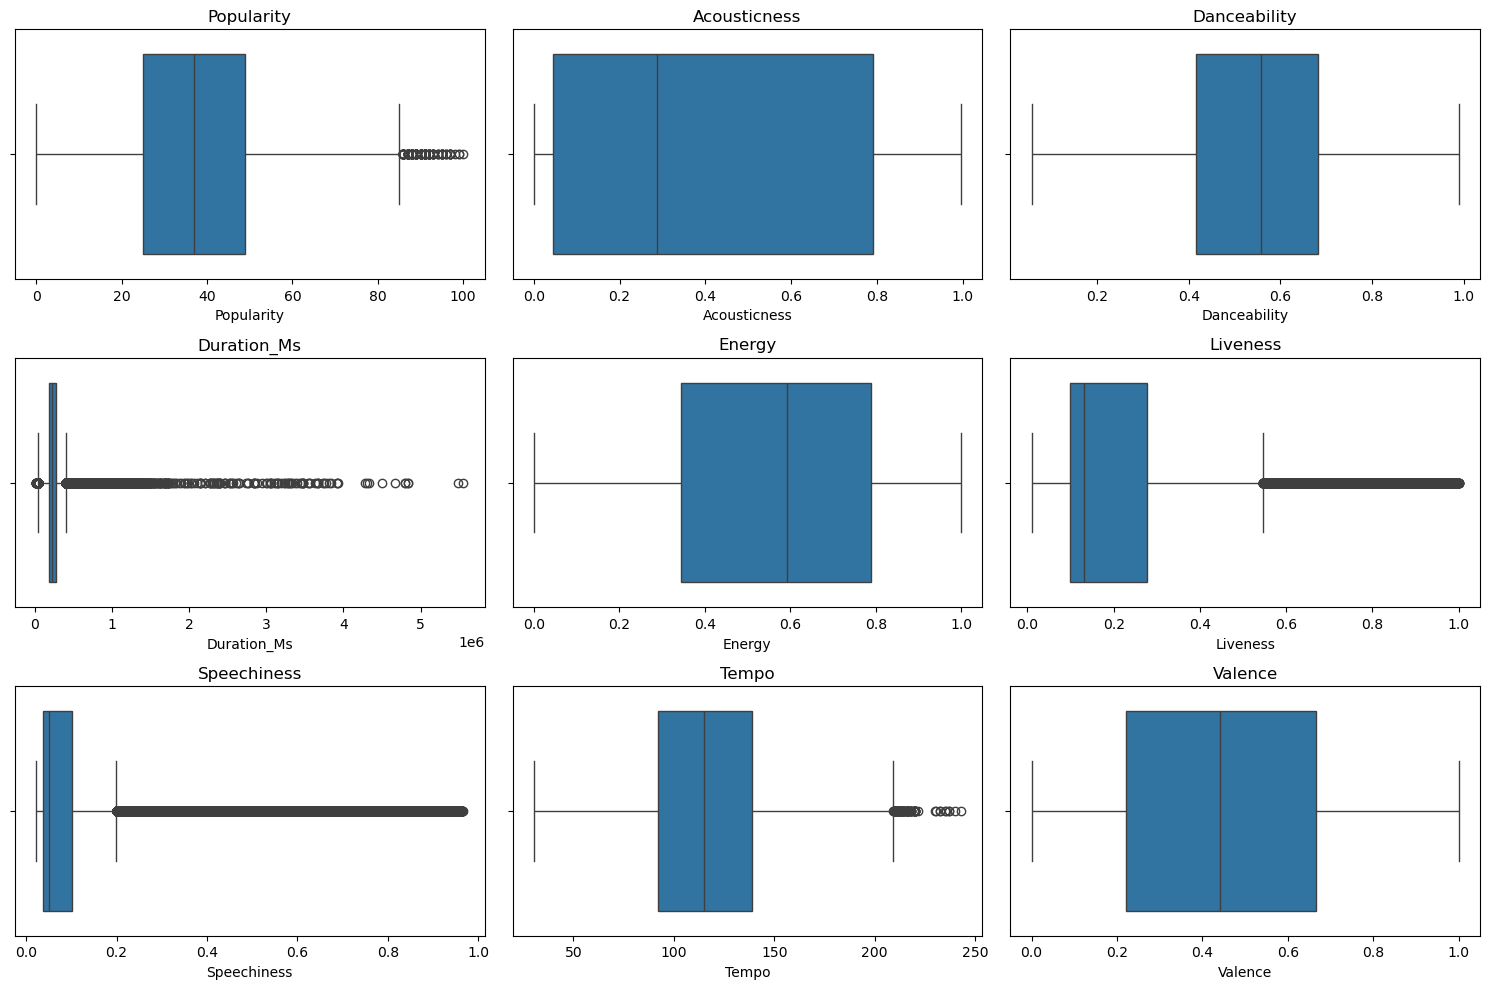

In [28]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Feature Relationships

In the next plot we can see the relationship between Energy and Danceability. Most tracks concantrate in the medium danceability to medium high energy. This suggests that songs with moderate levels of danceability tend to also have relatively high energy. However, high energy does not necessarily imply high danceability and similarly highly danceable songs are not always the most energetic.

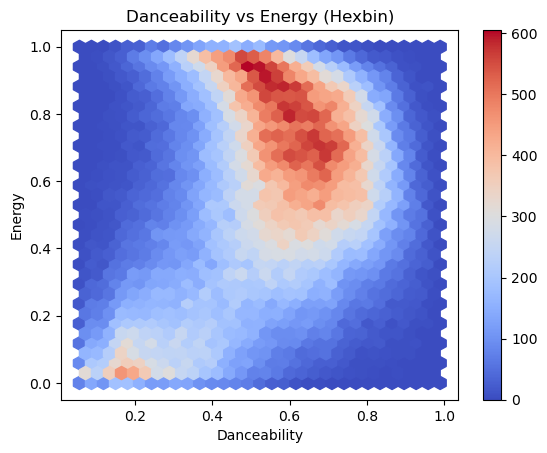

In [29]:
df.plot(kind='hexbin', x='Danceability', y='Energy', gridsize=30, cmap='coolwarm')
plt.title('Danceability vs Energy (Hexbin)')
plt.show()

In the following plot it is seen the correlation between numeric attributes. The strongest correlation is between `Valence` and `Danceability` indicating that more danceable songs tend to sound more positive and upbeat. Another interesting insight is between `Accousticness` and `Energy`, acoustic songs are less energetic, or we can say that are probably more calm. And third `Speechiness` and `Liveness` representing songs with more live characteristics tend to have more dialog like elements probably influenced by more interactions with crowds or spoken segments.

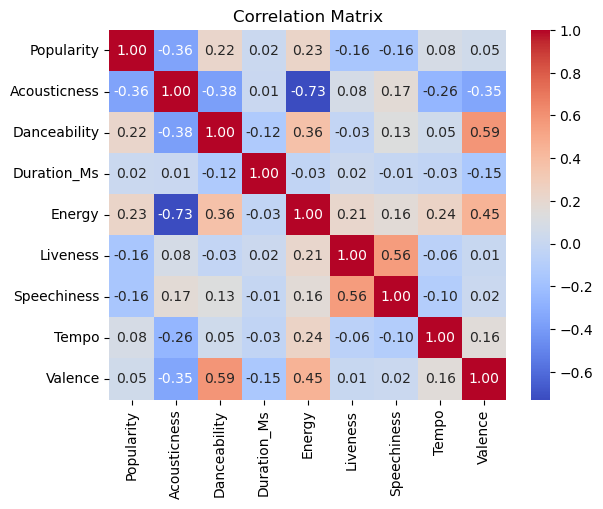

In [30]:
# Check correlation
df_corr = df[numeric_features].dropna().corr()
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Objective 3 - Identifying Relevant Information

For this objective the idea was to extract meaningful insights from the dataset by identifying relevant information such as the most danceable songs, the most popular artists, and the most danceable genres. This analysis aimed to answer specific data driven questions and highlight patterns within the dataset.


### Visualisation
The first analysis focuses on identifying the top 10 most danceable genres based on the average danceability score. Expectedely the top 3 genres are: Reggaeton, Hip-Hop, and Rap are considerable highly danceble modern genres. However, we can also see  Children's Music is in the top 5, this most likely due to characteristics of Children's music which tend to be very rhythmic and easy to follow e.g. clapping, jumping etc.

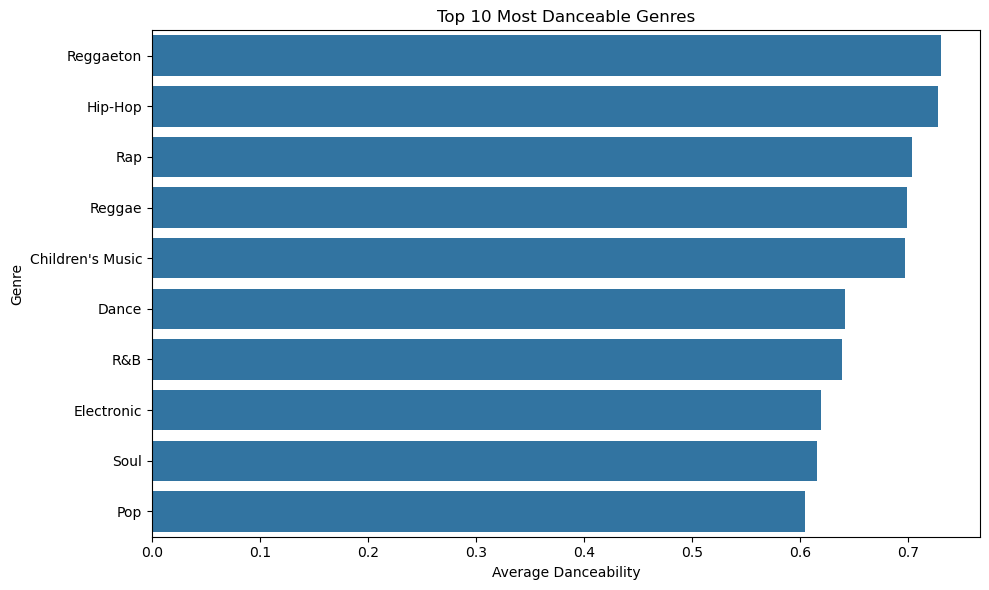

In [31]:
# What is the top 10 most danceable Genres?
top_genres = (
    df.groupby('Genre')['Danceability']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_genres,
    x='Danceability',
    y='Genre'
)

plt.title('Top 10 Most Danceable Genres')
plt.xlabel('Average Danceability')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()


In the next plot we see the most popular artists based on the average popularity of their tracks. Interestingly, the results are dominated by relatively modern or regionally popular artists rather than all time classics. This is due to Spotfy's popularity metric because it is influenced by recent trends and user engagement that all time classic may not have at a given time rather than historical significance. Additionally, using average popularity may favor artists with consistent popular tracks rather than one-hit wonders.

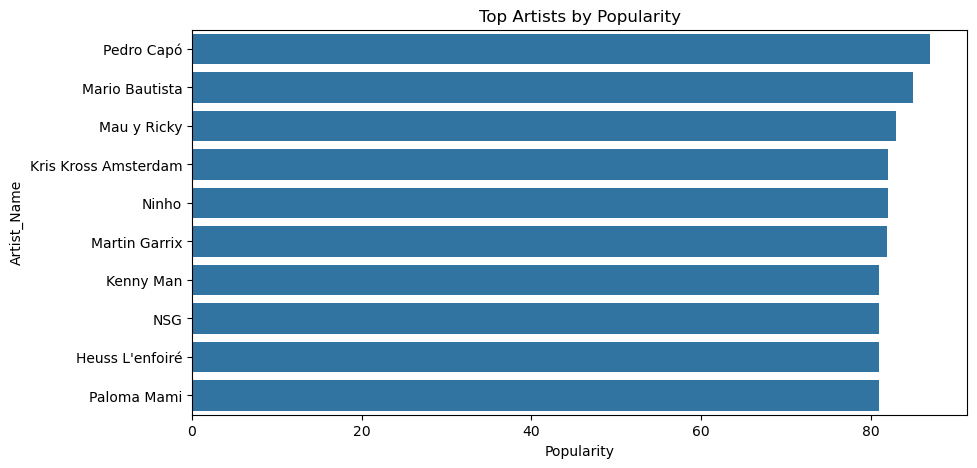

In [32]:
# What are the 10 most popular artists?
import seaborn as sns
import matplotlib.pyplot as plt
top_popular_artists = (
    df.groupby('Artist_Name')['Popularity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_popular_artists.reset_index(),
    x='Popularity',
    y='Artist_Name'
)
plt.title('Top Artists by Popularity')
plt.show()

On the other hand, if we would like to see a comparison between consistent popular artists and one-hit wonders or popularity driven by peaks of success. We could compare both and see the gaps between artists that have been consistently deliverying popular songs and artists that have high popular records but are not that popular in average.

In [33]:
# Group artists statistics by average and max popularity.
artist_stats = (
    df.groupby('Artist_Name')
    .agg(
        avg_popularity=('Popularity', 'mean'),
        max_popularity=('Popularity', 'max'),
        song_count=('Popularity', 'count')
    )
    .reset_index()
)

In [34]:
# Sort top artists by maximum popularity
top_artists = artist_stats.sort_values(
    by='max_popularity', ascending=False
).head(10)

For each artist two bars are displayed side by side: one for average popularity and one for maximum popularity. This allows for an easy visual comparison between an artist’s overall consistency (average) and their highest performing track (maximum).

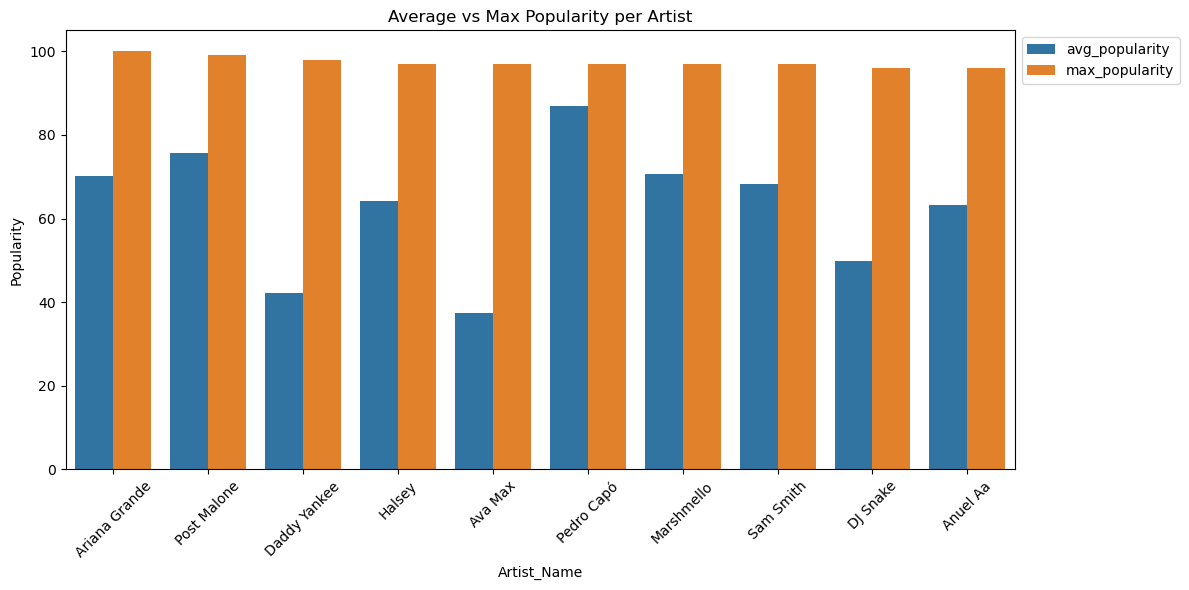

In [35]:
plot_df = top_artists.melt(
    id_vars='Artist_Name',
    value_vars=['avg_popularity', 'max_popularity'],
    var_name='Metric',
    value_name='Popularity'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_df,
    x='Artist_Name',
    y='Popularity',
    hue='Metric'
)

plt.xticks(rotation=45)
plt.title('Average vs Max Popularity per Artist')
plt.ylabel('Popularity')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Conclusion and presentation (10 marks)

### Achievements
The project successfully achieved its main objective of analysing and understanding the Spotify Tracks DB dataset through exploratory data analysis, correlation analysis, and visualisation techniques. The analysis provided meaningful insights into the structure and characteristics of the data, including the identification of outliers and skewed distributions. Relationships between key features such as danceability, energy, and acousticness were explored, revealing both expected and non intuitive patterns.

Additionally, the project was able to answer specific analytical questions, such as identifying the most danceable genres and the most popular artists. While genres like Reggaeton and Hip-Hop were expected to rank highly in terms of danceability, the presence of Children's Music among the top genres was an interesting and unexpected result, which was explained through the structural characteristics of such music. The comparison between average and maximum popularity also provided useful insight into the difference between consistent artists and those with single highly successful tracks.

### Limitations

Despite these achievements, the project has several limitations. The dataset is a static snapshot obtained from the Spotify API and may not fully reflect real-time listening trends. Additionally, the dataset appears to contain sampling bias, as it was constructed using a fixed number of tracks per genre, which may not represent real-world distributions. Some features, such as popularity, are dynamic and influenced by external factors e.g. Spotify algorithm criteria and trends, making them less reliable for a stable analysis.

### Future Work

Future work could extend this project by incorporating additional datasets or real-time Spotify data to provide a more comprehensive analysis. More advanced techniques, such as machine learning models, could be applied to predict song popularity or classify genres based on audio features.